In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("vinayakshanawad/meat-freshness-image-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'meat-freshness-image-dataset' dataset.
Path to dataset files: /kaggle/input/meat-freshness-image-dataset
Contents of base_path (/kaggle/input):
['meat-freshness-image-dataset']
Contents of path (/kaggle/input/meat-freshness-image-dataset):
['Meat Freshness.v1-new-dataset.multiclass']


In [ ]:
import os

# Update path based on cell 1 results
data_path = os.path.join(path, 'Meat Freshness.v1-new-dataset.multiclass')

# List class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Data classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Data classes found: ['valid', 'train']



--- Displaying sample images from dataset (/kaggle/input/meat-freshness-image-dataset/Meat Freshness.v1-new-dataset.multiclass) ---
Found 2266 images. Displaying 6 sample images:


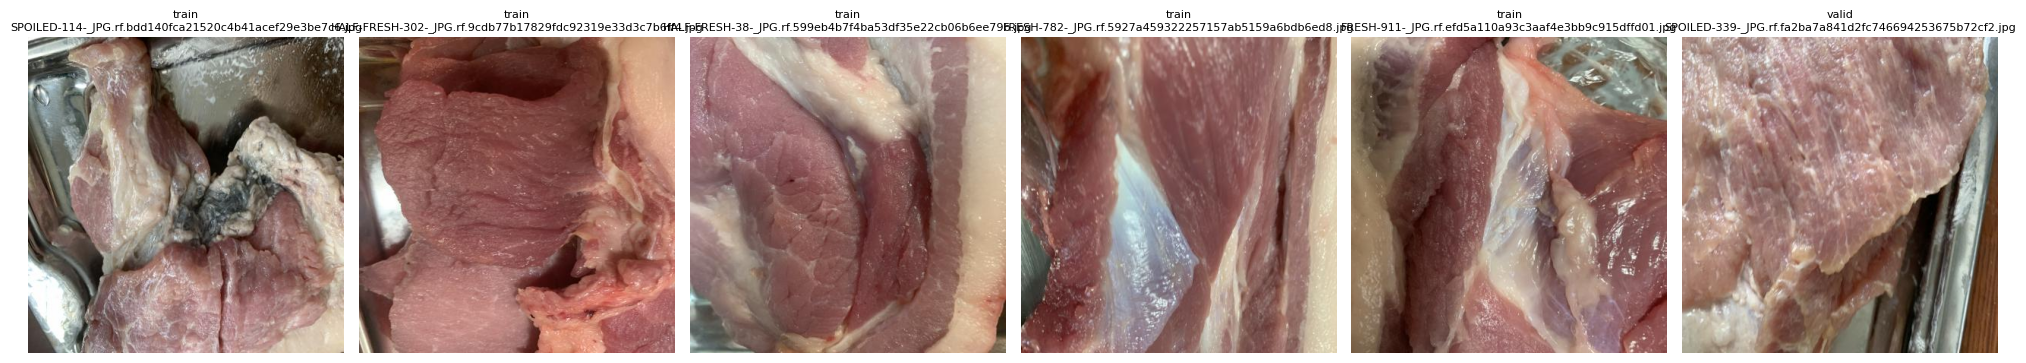

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use updated path
data_path = os.path.join(path, 'Meat Freshness.v1-new-dataset.multiclass')
print(f"\n--- Displaying sample images from dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import tensorflow as tf

# Check GPU availability
print("TensorFlow version:", tf.__version__)
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Please enable GPU in Notebook Settings.')
else:
  print('Found GPU at: {}'.format(device_name))

# List physical devices
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))

TensorFlow version: 2.20.0
Found GPU at: /device:GPU:0
Num GPUs Available:  1


In [ ]:
import pandas as pd
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def create_df(directory):
    files = [f for f in os.listdir(directory) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    labels = []
    for f in files:
        if 'FRESH' in f and 'HALF' not in f:
            labels.append('FRESH')
        elif 'HALF-FRESH' in f:
            labels.append('HALF-FRESH')
        elif 'SPOILED' in f:
            labels.append('SPOILED')
        else:
            labels.append('UNKNOWN')
    return pd.DataFrame({'filename': files, 'label': labels})

train_df = create_df(train_dir)
valid_df = create_df(valid_dir)

# Remove unknown labels if any
train_df = train_df[train_df['label'] != 'UNKNOWN']
valid_df = valid_df[valid_df['label'] != 'UNKNOWN']

print(f"Train samples:\n{train_df['label'].value_counts()}")

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=train_dir,
    x_col='filename',
    y_col='label',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_dataframe(
    valid_df,
    directory=valid_dir,
    x_col='filename',
    y_col='label',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Train samples:
label
FRESH         675
HALF-FRESH    630
SPOILED       510
Name: count, dtype: int64
Found 1815 validated image filenames belonging to 3 classes.
Found 451 validated image filenames belonging to 3 classes.


In [ ]:
import os

def list_structure(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        if dirs:
            continue
        for f in files[:3]:
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}...')

print("Cấu trúc thư mục train:")
list_structure(train_dir)
print("\nCấu trúc thư mục valid:")
list_structure(valid_dir)

Cấu trúc thư mục train:
train/
    SPOILED-176-_JPG.rf.5fe3730388fd8f01678c88598a5d433b.jpg
    SPOILED-268-_JPG.rf.0f5745e79434facfecd92bba2250d74d.jpg
    SPOILED-471-_JPG.rf.34f7be5756045f2662d8941cf971da34.jpg
    ...

Cấu trúc thư mục valid:
valid/
    FRESH-174-_JPG.rf.7a6b44877bd3c287f8eff0b39cbaa482.jpg
    HALF-FRESH-251-_JPG.rf.07bcc17218f507b4a6728c001b84183b.jpg
    HALF-FRESH-762-_JPG.rf.9d6f149d5327c8979a61c40869438e53.jpg
    ...


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

num_classes = len(train_generator.class_indices)
print(f"Number of classes detected: {num_classes}")

if num_classes > 0:
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    for layer in base_model.layers:
        layer.trainable = False

    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    print("Model compiled successfully.")
else:
    print("Error: No classes found.")

Number of classes detected: 3
Model compiled successfully.


In [ ]:
# Train the model
epochs = 10

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=epochs
)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.6865 - loss: 0.6787 - val_accuracy: 0.8281 - val_loss: 0.3638
Epoch 2/10
 1/56 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.8750 - loss: 0.3783

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8750 - loss: 0.3783 - val_accuracy: 0.7924 - val_loss: 0.4301
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 504ms/step - accuracy: 0.8592 - loss: 0.3392 - val_accuracy: 0.9308 - val_loss: 0.1838
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9375 - loss: 0.2224 - val_accuracy: 0.9442 - val_loss: 0.1789
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 496ms/step - accuracy: 0.9057 - loss: 0.2395 - val_accuracy: 0.8929 - val_loss: 0.2324
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9565 - loss: 0.1530 - val_accuracy: 0.8884 - val_loss: 0.2436
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 484ms/step - accuracy: 0.9136 - loss: 0.2149 - val_accuracy: 0.9464 - val_loss: 0.1395
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9688 - loss: 0.0812 - val_accuracy: 0.9531 - val_loss: 0.1345
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 476ms/step - accuracy: 0.9305 - loss: 0.1841 - val_accuracy: 0.9598 - val_

In [ ]:
# Summary of training results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"--- Training Summary ---")
print(f"Training Accuracy: {final_train_acc:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")
print(f"Training Loss: {final_train_loss:.4f}")
print(f"Validation Loss: {final_val_loss:.4f}")

--- Training Summary ---
Training Accuracy: 0.9375
Validation Accuracy: 0.9576
Training Loss: 0.2153
Validation Loss: 0.1283


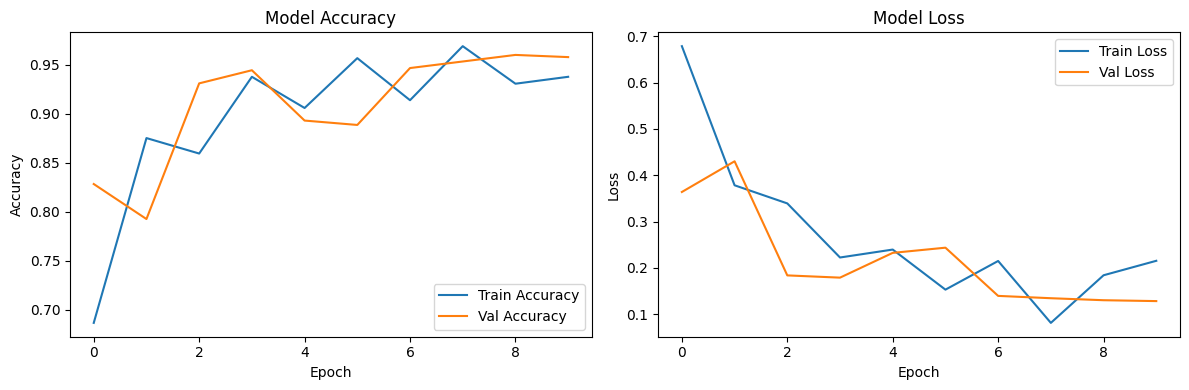

In [ ]:
# Visualize training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()